In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections.abc import Mapping
from IPython.display import display
from plotting_utils import create_df_runs, apply_presentation_theme
from matplotlib.container import BarContainer
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [22]:
#df_runs = create_df_runs()
df_runs = create_df_runs(hypothesis_to_filter="structured_spec_conversational_reruns")

df_runs created and its head looks like this:


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,13,13,2026-06-02T17:27:56.534698__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,5b3c0cd5,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
1,29,29,2026-06-02T12:22:25.400514__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,36223bca,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
2,63,63,2026-06-03T14:45:53.748964__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,68d96cff,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
3,71,72,2026-06-03T11:47:10.556439__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,cdf3ac92,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
4,76,77,2026-06-02T14:10:19.298501__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,a285b287,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, StructuredSpecification-ChildBenefit-v2.md, False)",6


In [23]:
df_runs.columns

Index(['level_0', 'index', 'run_name', 'model', 'prompt', 'url_allowed',
       'commit', 'hypothesis_name', 'results', 'prompt_name', 'prompt_type',
       'model_name', 'config_key', 'prompt_version', 'config_label'],
      dtype='object')

In [24]:
def build_case_category_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    expected = []
    actual = []

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            #if case_id not in expected:
            #    expected[case_id] = {}
            #if case_id not in actual:
            #    actual[case_id] = {}
            #records[case_id][run_name] = case_data.get("child_evaluations", [])
            #records[case_id][run_name] = [(child["expected_eligible"], child["actual_eligible"]) for child in case_data.get("child_evaluations", []).values()]

            #actual[case_id][run_name] = [child["actual_eligible"] for child in case_data.get("child_evaluations", []).values()]
            #expected[case_id][run_name] = [child["expected_eligible"] for child in case_data.get("child_evaluations", []).values()]

            actual.extend([[case_id, run_name, child_name, child.get("actual_eligible")] for child_name, child in case_data.get("child_evaluations", []).items()])
            expected.extend([[case_id, run_name, child_name, child.get("expected_eligible")] for child_name, child in case_data.get("child_evaluations", []).items()])

    #df_matrix = pd.DataFrame.from_dict(records, orient="index")
    actual_df = pd.DataFrame.from_records(
        actual, 
        columns=["CaseId", "RunName", "ChildName", "Eligibility"],
        index=["CaseId", "RunName", "ChildName"],
    )
    expected_df = pd.DataFrame.from_records(
        expected, 
        columns=["CaseId", "RunName", "ChildName", "Eligibility"],
        index=["CaseId", "RunName", "ChildName"],
    )
    # See "analysis/testOutputs/child_benefit/2026-05-18T12:14:53.570138__Model=claude-sonnet-4-5__Commit=759efcde/concatenated_test_uncertainty_cases/Permutation_RND_SET_2_014.conversation.json"
    # for an example of where for some reason the agent has used the value of the enumeration rather than the key
    actual_df["Eligibility"] = actual_df["Eligibility"][actual_df["Eligibility"].isin(["ELIGIBLE", "INELIGIBLE", "INDETERMINATE"])]
    expected_df["Eligibility"] = expected_df["Eligibility"][actual_df["Eligibility"].isin(["ELIGIBLE", "INELIGIBLE", "INDETERMINATE"])]

    
    actual_df["Eligibility"] = actual_df["Eligibility"].astype("category")
    expected_df["Eligibility"] = expected_df["Eligibility"].astype("category")

    return actual_df, expected_df


In [25]:
df_runs


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,13,13,2026-06-02T17:27:56.534698__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,5b3c0cd5,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
1,29,29,2026-06-02T12:22:25.400514__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,36223bca,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
2,63,63,2026-06-03T14:45:53.748964__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,68d96cff,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
3,71,72,2026-06-03T11:47:10.556439__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,cdf3ac92,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
4,76,77,2026-06-02T14:10:19.298501__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,a285b287,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
5,87,88,2026-06-02T16:12:53.291662__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,4bdd97f2,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...


In [26]:
actual, expected = build_case_category_matrix(df_runs)


In [27]:
actual["Eligibility"].value_counts()

Eligibility
INELIGIBLE       707
ELIGIBLE         683
INDETERMINATE    352
Name: count, dtype: int64

In [28]:
expected["Eligibility"].value_counts()

Eligibility
INDETERMINATE    647
INELIGIBLE       551
ELIGIBLE         544
Name: count, dtype: int64

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le_actual = le.fit_transform(actual.dropna())
le_expected = le.fit_transform(expected.dropna())

/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [30]:
le.classes_

array(['ELIGIBLE', 'INDETERMINATE', 'INELIGIBLE'], dtype=object)

In [31]:
plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 13


Accuracy score: 73.19173363949484%


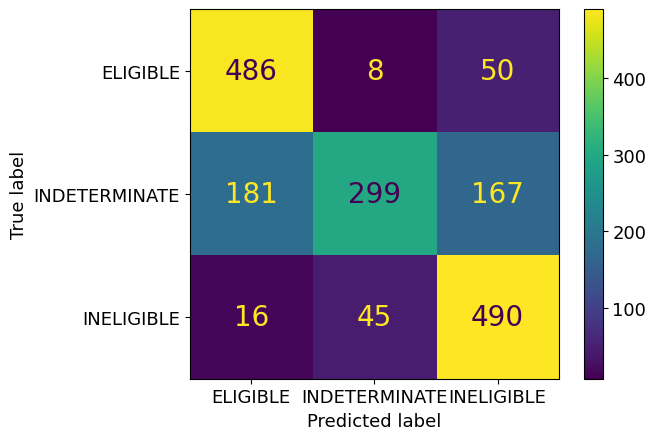

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

cm = confusion_matrix(
    y_true=le_expected, 
    y_pred=le_actual,
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
#plt.title("Confusion Matrix describing children associated with all runs")

score = accuracy_score(
    y_true=le_expected, 
    y_pred=le_actual,
)
print(f"Accuracy score: {score*100}%")

# What are the results?

* The numbers you see represent per-child eligilbity assessments made over 6 full test runs, each containing 199 test cases 
  * Each of the test cases we have generated describes one or more children in a family
  * It is possible for one child in a family to be eligible for child benefit but another child ineligble for child benefit
* The vertical axis represents the response the agent should have given
* The horizonal axis represents the response the agent actually gave
* `INDETERMINATE` is another way of saying that the answer can't be determined
* Any answers in the top-left to bottom-right diagonal (i.e. the ones with 406, 253, 412) are correct answers
  * This is because this is where the response the agent should have given and the response it gave are the same

## What do these tell us?
* We can see a much lower overall accuracy compared to the conversational runs for free text results.
* A less desirable failure mode; where results that should be `INDETERMINATE` are assigned `INELIGIBLE` by the agent.
    * This is less desirable as we can posit that in the real world, it would discourage applicants whose eligiblity cannot be determined by the system (that could potentially be successful) from applying.
* Further analysis would need to be done on the agent reasoning provided in the raw data in order to further establish the reason for these results being less favourable than the free text rules. 

In [33]:
def build_case_reliability_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Build a pass/fail matrix for one configuration across multiple runs.

    Rows = case IDs
    Columns = run names
    Values = boolean pass/fail
    """
    records: dict[str, dict[str, bool]] = {}

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            if case_id not in records:
                records[case_id] = {}

            records[case_id][run_name] = case_data.get("overall_is_correct", False)

    df_matrix = pd.DataFrame.from_dict(records, orient="index")

    df_matrix["Pass_Rate"] = df_matrix.mean(axis=1)

    df_matrix["Category"] = pd.cut(
        df_matrix["Pass_Rate"],
        bins=[-0.1, 0.0, 0.99, 1.0],
        labels=["Systematic Fail", "Flaky", "Always Passes"],
    )

    return df_matrix


def build_reliability_matrices_by_config(
    df_runs: pd.DataFrame,
    min_runs: int = 3,
) -> dict[str, pd.DataFrame]:
    """
    Build one reliability matrix per configuration, keeping only configurations
    with at least `min_runs` runs.
    """
    # Group by the clean config_label instead of the tuple
    config_counts = df_runs["config_label"].value_counts()
    eligible_config_labels = config_counts[config_counts >= min_runs].index.tolist()

    matrices = {}

    for config_label in eligible_config_labels:
        target_runs = df_runs.loc[df_runs["config_label"] == config_label]
        matrices[config_label] = build_case_reliability_matrix(target_runs)

    return matrices

In [34]:
reliability_matrices = build_reliability_matrices_by_config(df_runs, min_runs=1)

for config_key, df_matrix in reliability_matrices.items():
    print(f"\n=== Reliability Summary: {config_key} ===")
    display(df_matrix["Category"].value_counts().to_frame("Number of Cases"))

    hard_cases = df_matrix[df_matrix["Pass_Rate"] < 1.0].sort_values("Pass_Rate")
    if not hard_cases.empty:
        print("\n🚨 Examples of flaky and Failing Cases:")
        display(hard_cases[["Pass_Rate", "Category"]].head(10))


=== Reliability Summary: claude-sonnet-4-5 | Structured spec with indeterminacy ===


,Number of Cases
Category,
Always Passes,87
Flaky,77
Systematic Fail,35



🚨 Examples of flaky and Failing Cases:


,Pass_Rate,Category
APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_013,0.0,Systematic Fail
RESPONSIBILITY_INDET_PRIORITY_UNKNOWN_RND_026,0.0,Systematic Fail
INFORMAL_ARRANGEMENT_INDET_BASIC_RND_016,0.0,Systematic Fail
ADOPTION_INDET_BEFORE_CHILD_MOVES_IN_RND_058,0.0,Systematic Fail
APPRENTICESHIP_INDET_STATUS_UNKNOWN_RND_030,0.0,Systematic Fail
APPRENTICESHIP_LOCATION_INDET_WALES_RND_012,0.0,Systematic Fail
CHILD_BENEFITS_INDET_BENEFIT_STATUS_UNKNOWN_RND_011,0.0,Systematic Fail
CHILD_BENEFITS_INDET_BENEFIT_STATUS_UNKNOWN,0.0,Systematic Fail
CHILD_BENEFITS_INDET_BENEFIT_STATUS_UNKNOWN_RND_071,0.0,Systematic Fail
APPRENTICESHIP_LOCATION_INDET_WALES_RND_072,0.0,Systematic Fail


/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Text(0.5, 1.0, 'Confusion Matrix describing describing children associated with cases which have no successful runs')

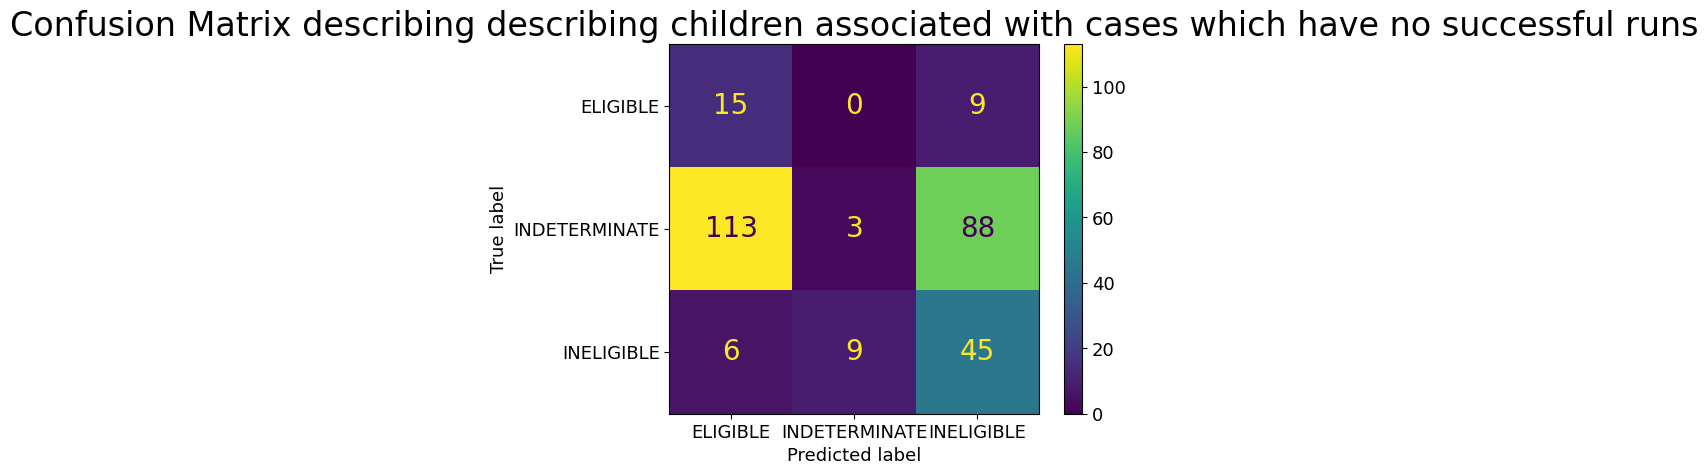

In [35]:
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
le = LabelEncoder()
cm = confusion_matrix(
    y_true=le.fit_transform(
        expected
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Systematic Fail"
            ].index
        ]
    ),
    y_pred=le.fit_transform(
        actual
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Systematic Fail"
            ].index
        ]
    ),
)
#print(le.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
plt.title("Confusion Matrix describing describing children associated with cases which have no successful runs")



['ELIGIBLE' 'INDETERMINATE' 'INELIGIBLE']


/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Text(0.5, 1.0, 'Confusion Matrix describing children associated with cases which sometimes pass & sometimes fail')

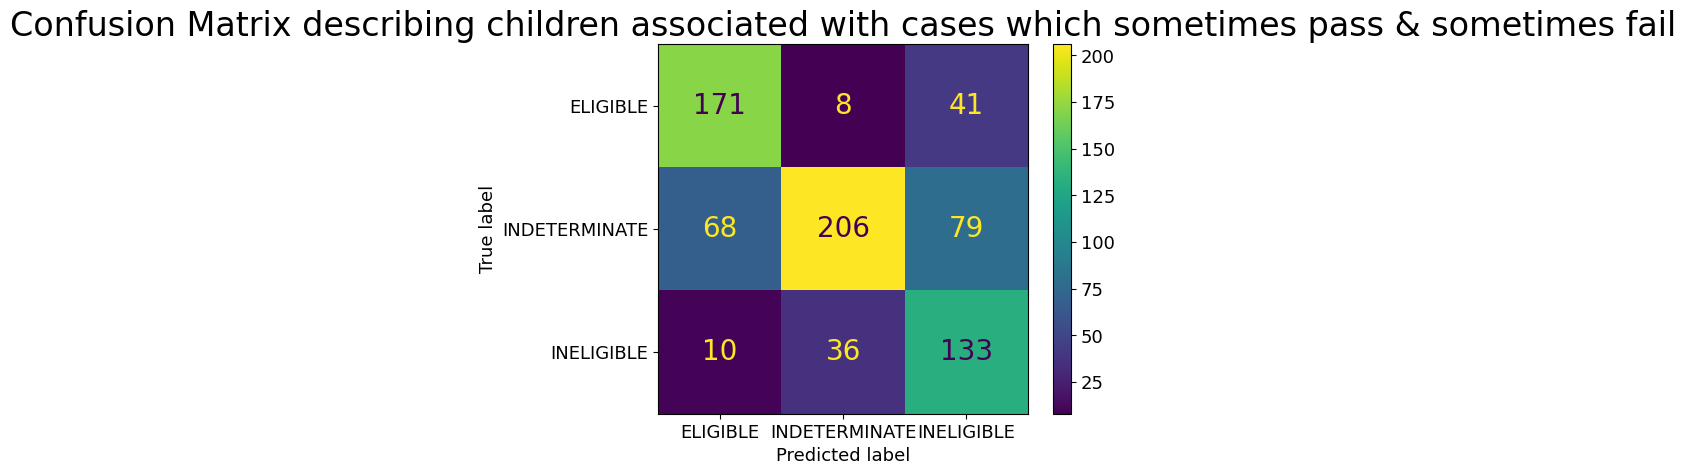

In [36]:
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#le = LabelEncoder()
cm = confusion_matrix(
    y_true=le.fit_transform(
        expected
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Flaky"
            ].index
        ]
    ),
    y_pred=le.fit_transform(
        actual
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Flaky"
            ].index
        ]
    ),
)
print(le.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
plt.title("Confusion Matrix describing children associated with cases which sometimes pass & sometimes fail")


# Next Steps

* Further analysis to identify any further commonalities amongst failiure modes that might help us iterate
* Control for "actor hallucination" by adding further runs using the "facts-bundle" approach i.e. without an actor agent

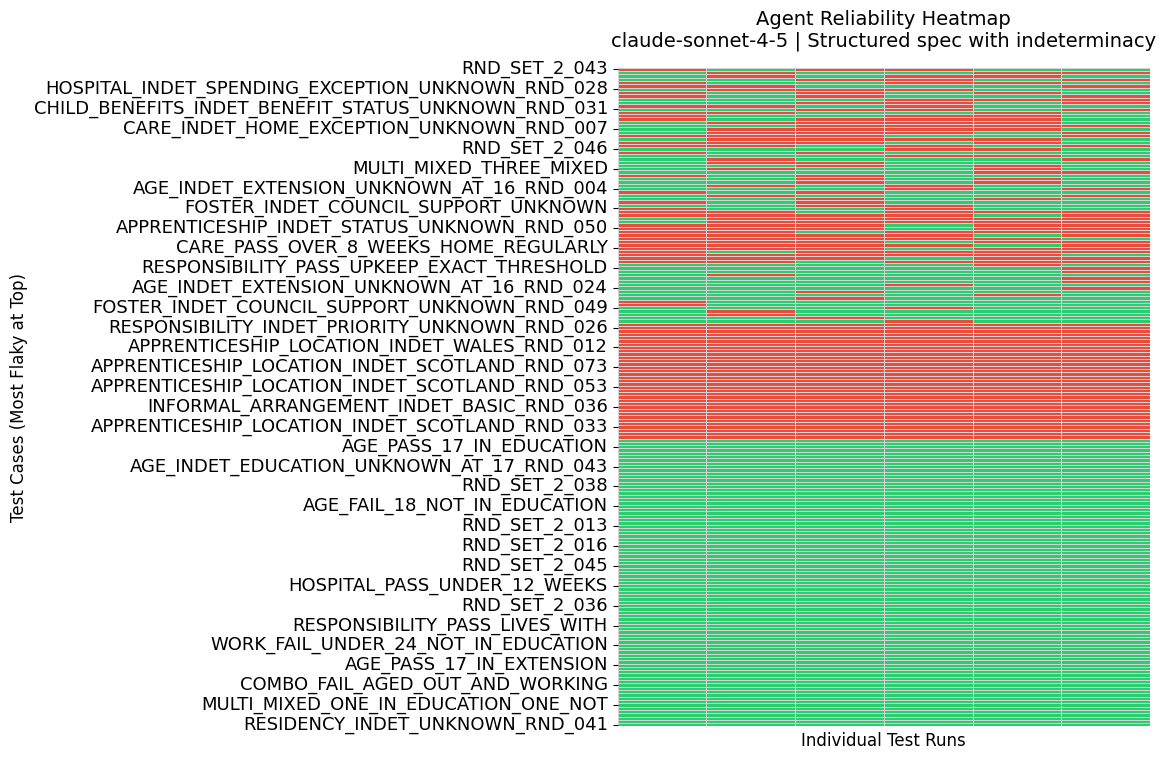

In [37]:
def plot_reliability_heatmaps(
    reliability_matrices: dict[str, pd.DataFrame],
) -> None:
    """
    Plot a reliability heatmap for each configuration.
    Sorted by variance (flakiness) so unreliable cases sit at the top.
    """
    cmap = sns.color_palette(["#e74c3c", "#2ecc71"])

    # Dictionary key is now just the string label
    for config_label, df_matrix in reliability_matrices.items():
        run_cols = [c for c in df_matrix.columns if c not in ["Pass_Rate", "Category"]]
        df_matrix["Flakiness"] = df_matrix[run_cols].var(axis=1)
        df_sorted = df_matrix.sort_values(
            by=["Flakiness", "Pass_Rate"], ascending=[False, True]
        )

        heatmap_data = df_sorted[run_cols].astype(float)

        if heatmap_data.empty:
            continue

        plt.figure(figsize=(12, 8))

        sns.heatmap(
            heatmap_data,
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor="lightgray",
            xticklabels=False,
        )

        # Use the config_label directly in the title
        plt.title(
            f"Agent Reliability Heatmap\n{config_label}",
            fontsize=14,
            pad=15,
        )

        plt.xlabel("Individual Test Runs", fontsize=12)
        plt.ylabel("Test Cases (Most Flaky at Top)", fontsize=12)

        plt.tight_layout()
        plt.show()


plot_reliability_heatmaps(reliability_matrices)

In [38]:
def plot_comparative_reliability(reliability_matrices: dict[str, pd.DataFrame]) -> None:
    """
    Creates a 100% stacked bar chart comparing the reliability
    and accuracy of different agent configurations.
    """
    records = []

    for config_label, df_matrix in reliability_matrices.items():
        # Calculate the percentage of cases in each category
        category_percentages = df_matrix["Category"].value_counts(normalize=True) * 100

        records.append(
            {
                "Configuration": config_label,  # Mapped directly!
                "Always Passes": category_percentages.get("Always Passes", 0),
                "Systematic Fail": category_percentages.get("Systematic Fail", 0),
                "Flaky (Non-Deterministic)": category_percentages.get("Flaky", 0),
            }
        )

    df_plot = pd.DataFrame(records).set_index("Configuration")

    # Sort the dataframe so the most reliable configs (lowest Flaky rate) are at the top
    df_plot = df_plot.sort_values(by="Flaky (Non-Deterministic)", ascending=True)

    # Plotting
    colors = ["#2ecc71", "#e74c3c", "#f1c40f"]  # Green, Red, Yellow

    ax = df_plot[
        ["Always Passes", "Systematic Fail", "Flaky (Non-Deterministic)"]
    ].plot(
        kind="barh",
        stacked=True,
        figsize=(12, max(4, len(df_plot) * 1.2)),
        color=colors,
        width=0.7,
    )

    plt.title("Configuration Comparison: Reliability vs. Accuracy", fontsize=16, pad=20)
    plt.xlabel("Percentage of Test Cases (%)", fontsize=12)
    plt.ylabel("")

    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for container in ax.containers:
        for p in container:
            width = p.get_width()
            if width > 3:
                ax.annotate(
                    f"{width:.1f}%",
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=10,
                    fontweight="bold",
                )

    plt.tight_layout()
    plt.show()

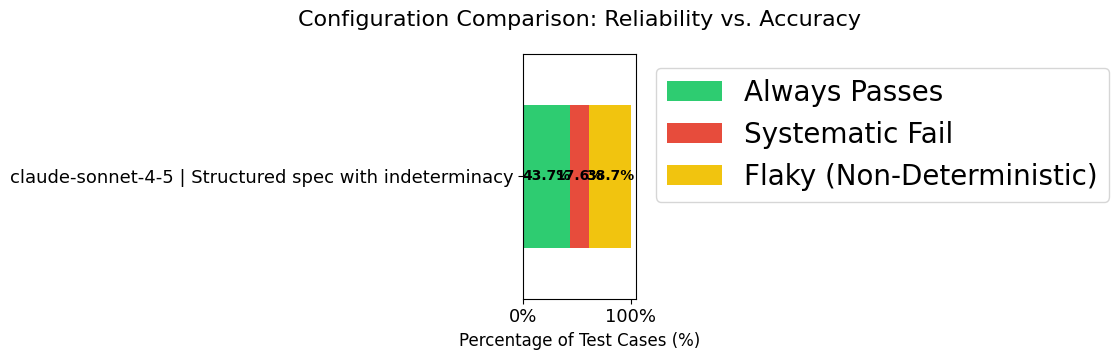

In [39]:
plot_comparative_reliability(reliability_matrices)